In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [53]:
df = pd.read_csv("Dataset/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [54]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [55]:
# Rename columns for easier access
df = df.rename(columns={
    "parental level of education": "parent_education",
    "test preparation course": "test_prep",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})

# Calculate average score
df["average_score"] = (
                              df["math_score"] +
                              df["reading_score"] +
                              df["writing_score"]
                      ) / 3

df.head()

,gender,race/ethnicity,parent_education,lunch,test_prep,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


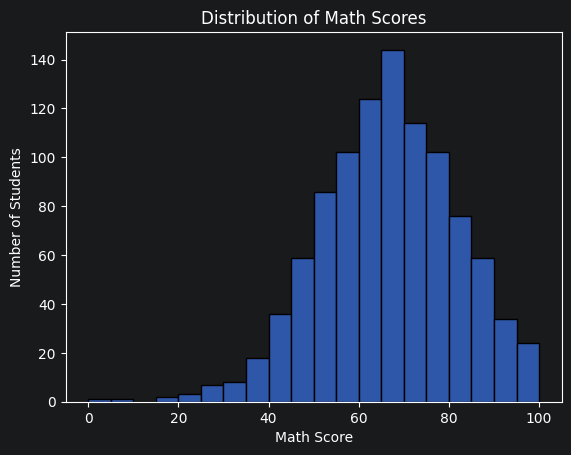

In [56]:
plt.figure()
sns.histplot(df["math_score"], bins=20)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.show()

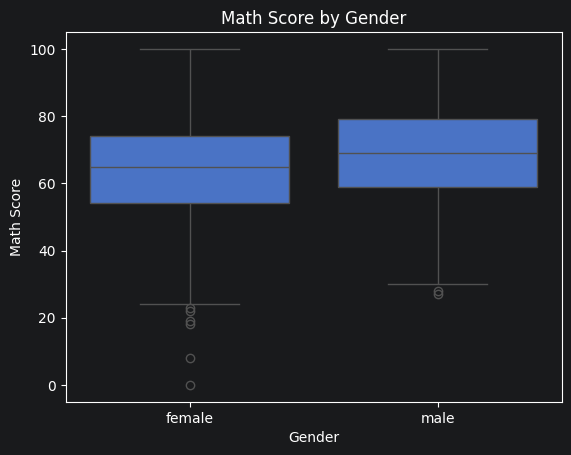

In [57]:
plt.figure()
sns.boxplot(data=df, x="gender", y="math_score")
plt.title("Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

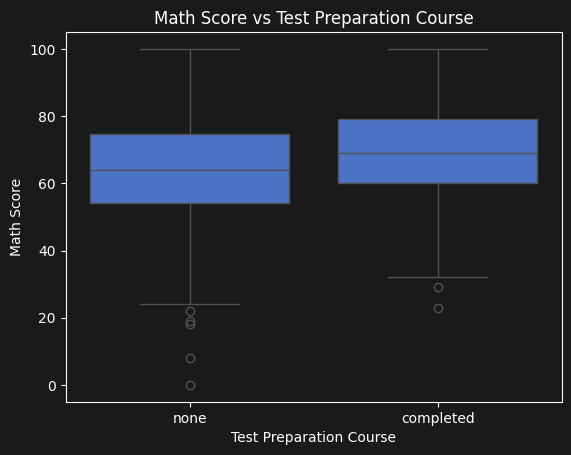

In [58]:
plt.figure()
sns.boxplot(data=df, x="test_prep", y="math_score")
plt.title("Math Score vs Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

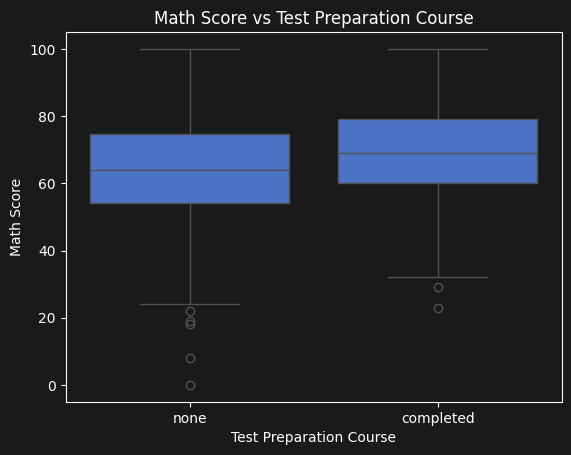

In [59]:
plt.figure()
sns.boxplot(data=df, x="test_prep", y="math_score")
plt.title("Math Score vs Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()


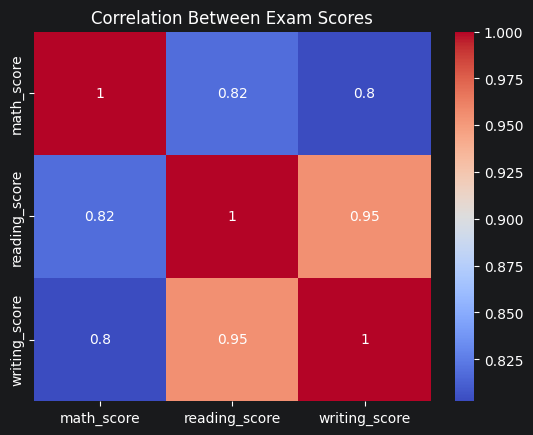

In [60]:
corr = df[["math_score", "reading_score", "writing_score"]].corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Exam Scores")
plt.show()

In [61]:
# 1. Convert categorical variables to numeric (0 and 1) safely using .replace()
# This prevents the NaN ValueError if run multiple times!
df['test_prep'] = df['test_prep'].replace({'none': 0, 'completed': 1})
df['lunch'] = df['lunch'].replace({'free/reduced': 0, 'standard': 1})

# 2. Define Features (X) and Target (y)
X = df[['reading_score', 'writing_score', 'test_prep', 'lunch']]
y = df['math_score']

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Test the model and calculate accuracy metrics
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared Score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

R-squared Score: 0.70
Mean Squared Error: 72.78


In [62]:
      # 6. View the Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,reading_score,0.592325
1,writing_score,0.215599
2,test_prep,-0.430276
3,lunch,5.492977
